## Foundations of Machine Learning Frameworks CSCN8010

### Practical Lab 3 - Vanilla CNN and Fine-Tune VGG16 - for Dogs and Cats Classification

### Name- Kumari Nikitha Singh
### Student ID- 9053016

### Step 1: Dataset Preparation

We begin by extracting the `kaggle_dogs_vs_cats_small.zip` dataset and flattening the folder structure to avoid issues like `__MACOSX`. The dataset is divided into three subsets:

- `train/`: Used to train the models
- `validation/`: Used to monitor validation loss and prevent overfitting
- `test/`: Used for final model evaluation


In [1]:
import zipfile
from pathlib import Path

# Set paths
zip_path = Path().resolve() / "kaggle_dogs_vs_cats_small.zip"
extract_to = Path().resolve() / "kaggle_dogs_vs_cats_small"

# Extract into correct structure (remove top-level folder)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for member in zip_ref.infolist():
        member_path = Path(member.filename)

        # Skip hidden files (like __MACOSX)
        if member_path.parts[0].startswith("__") or member_path.name.startswith("."):
            continue

        # Remove top folder level
        relative_path = Path(*member_path.parts[1:])

        # Target extraction path
        target_path = extract_to / relative_path

        # Create parent directories if needed
        target_path.parent.mkdir(parents=True, exist_ok=True)

        # Extract file
        if not member.is_dir():
            with zip_ref.open(member) as source, open(target_path, 'wb') as target:
                target.write(source.read())

print(" Flattened extraction complete.")


 Flattened extraction complete.


### Step 2: Image Count Verification

To ensure the dataset is balanced and properly structured, we count the number of images in each split (`train`, `validation`, `test`) and for each class (`cat`, `dog`).

This step helps verify:
- Dataset integrity
- Equal distribution across classes
- No missing or extra files

The results are presented in a tabular format using a pandas DataFrame.


In [2]:
from collections import defaultdict

# Count images
image_counts = defaultdict(dict)

for split in ["train", "validation", "test"]:
    for category in ["cat", "dog"]:
        folder = extract_to / split / category
        count = len(list(folder.glob("*.jpg")))
        image_counts[split][category] = count

# Display counts
import pandas as pd
df_counts = pd.DataFrame(image_counts)
df_counts


,train,validation,test
cat,1000,500,250
dog,1000,500,250


### Step 3: Sample Image Visualization

To understand the nature of the dataset, we display a few sample images from both the `cat` and `dog` classes. This helps us visually inspect:

- Image clarity and variety
- Class balance
- Pose, lighting, and background diversity

Visual inspection provides an intuitive understanding of the dataset before training.


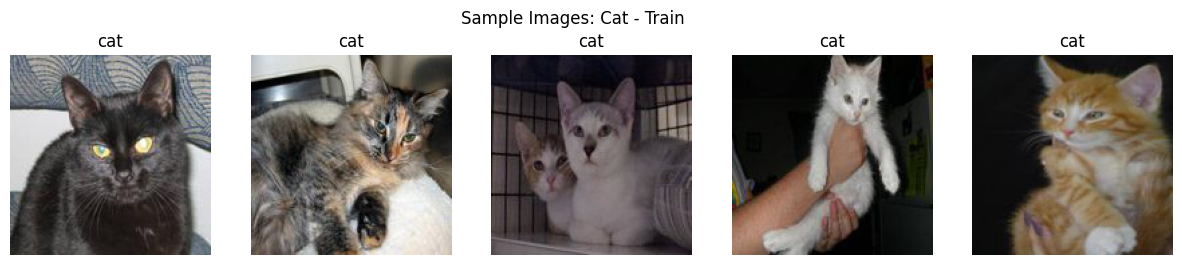

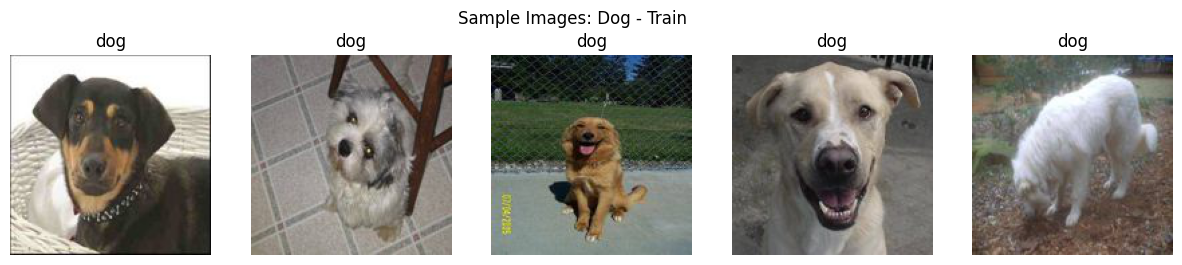

In [3]:
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_samples(split='train', category='cat', num_images=5):
    folder = extract_to / split / category
    files = list(folder.glob("*.jpg"))
    samples = random.sample(files, min(num_images, len(files)))

    plt.figure(figsize=(15, 3))
    for idx, file in enumerate(samples):
        img = Image.open(file)
        plt.subplot(1, num_images, idx+1)
        plt.imshow(img)
        plt.title(f"{category}")
        plt.axis('off')
    plt.suptitle(f"Sample Images: {category.capitalize()} - {split.capitalize()}")
    plt.show()

# Show both classes
show_samples('train', 'cat')
show_samples('train', 'dog')


### Step 4: Image Dimension Consistency

We check whether all images have the same width and height. This is crucial because neural networks expect uniform input shapes.

- If all images have the same dimensions → proceed.
- If variations exist → resizing is required (we resize to 150x150 later).

Inconsistent dimensions can affect batch processing and model accuracy.


In [4]:
from PIL import Image
from pathlib import Path

# Set root directory
base_dir = extract_to  # already flattened to 'kaggle_dogs_vs_cats_small'
unique_shapes = set()

# Collect shapes
for split in ["train", "validation", "test"]:
    for category in ["cat", "dog"]:
        folder = base_dir / split / category
        for img_file in folder.glob("*.jpg"):
            try:
                with Image.open(img_file) as img:
                    unique_shapes.add(img.size)  # (width, height)
            except:
                continue

# Output results
if len(unique_shapes) == 1:
    print(f" All images have the same shape: {unique_shapes.pop()}")
else:
    print(f" Found {len(unique_shapes)} unique image shapes:")
    for shape in unique_shapes:
        print(f" - {shape}")


 All images have the same shape: (150, 150)


### Step 5: Width and Height Distribution

We plot histograms of image width and height across the dataset to visually assess size variation.

Understanding dimension distribution helps validate our resizing decision and ensures no images are too small or too large.


In [5]:
from PIL import Image
import pandas as pd

# Collect width and height of all images
image_dimensions = []

for split in ["train", "validation", "test"]:
    for category in ["cat", "dog"]:
        folder = extract_to / split / category
        for img_file in folder.glob("*.jpg"):
            try:
                with Image.open(img_file) as img:
                    width, height = img.size
                    image_dimensions.append({
                        "Split": split,
                        "Category": category,
                        "Width": width,
                        "Height": height
                    })
            except:
                continue

# Create DataFrame
df_dims = pd.DataFrame(image_dimensions)


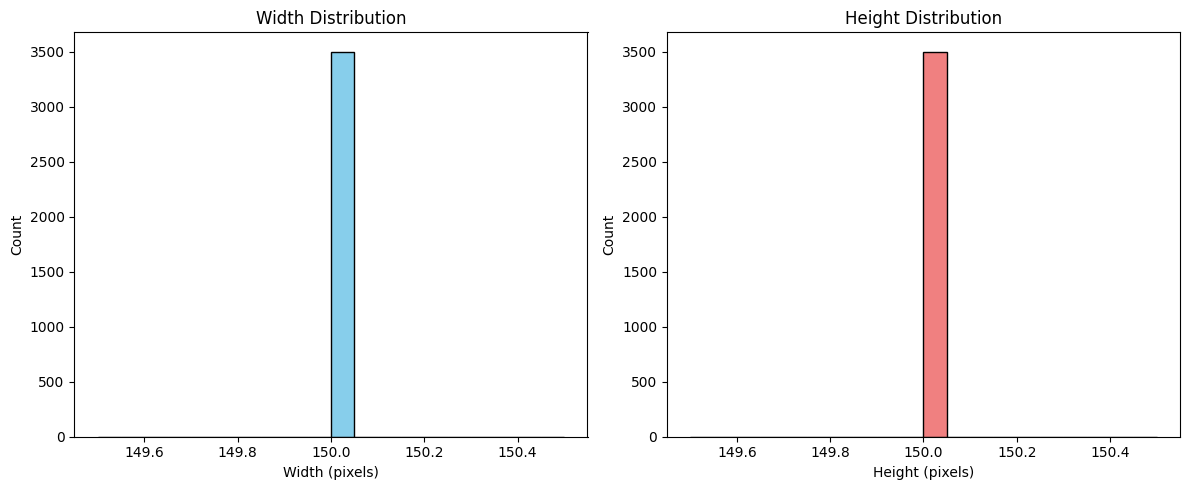

In [6]:
import matplotlib.pyplot as plt

# Basic histograms
plt.figure(figsize=(12, 5))

# Width
plt.subplot(1, 2, 1)
plt.hist(df_dims["Width"], bins=20, color="skyblue", edgecolor="black")
plt.title("Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Count")

# Height
plt.subplot(1, 2, 2)
plt.hist(df_dims["Height"], bins=20, color="lightcoral", edgecolor="black")
plt.title("Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


### Step 6: Data Augmentation Strategy

To improve model generalization and prevent overfitting, we apply the following augmentations on the training data using `ImageDataGenerator`:

- `rotation_range=20`: Random rotation ±20°
- `zoom_range=0.2`: Random zoom in/out
- `horizontal_flip=True`: Random left-right flips
- `width_shift_range=0.1` and `height_shift_range=0.1`: Random translation
- `rescale=1./255`: Normalize pixel values to 0–1

These augmentations increase dataset diversity and simulate real-world variability in images.

### Augmented Batch – Multiple Images

We apply the above augmentations to a random batch of **6 different images** from the training set and display the results.

This demonstrates how the model sees different transformations during training, even for different images in each epoch.


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Define image parameters
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32


Resolved Train Directory: d:\Data\kaggle_dogs_vs_cats_small\train
Found 2000 images belonging to 2 classes.


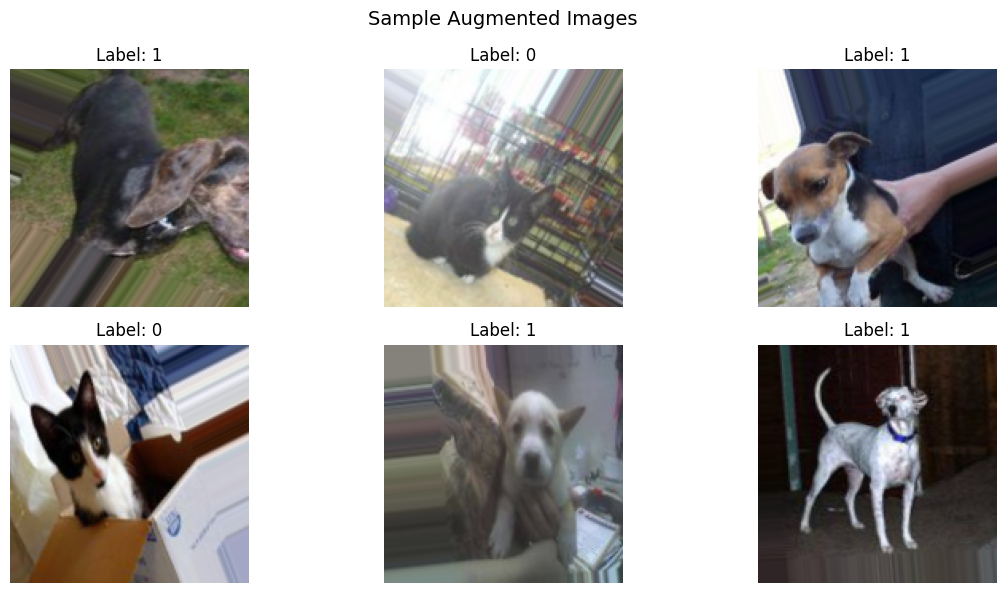

In [8]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#  Base project directory (auto-detects current file location)
base_dir = Path.cwd()

# Relative path to the train folder
train_dir = base_dir / "kaggle_dogs_vs_cats_small" / "train"

# Check path
print("Resolved Train Directory:", train_dir)
assert train_dir.exists(), f"❌ Folder not found: {train_dir}"

#  Image settings
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 6

# Data augmentation generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Flow from directory
aug_gen_all = train_datagen.flow_from_directory(
    str(train_dir),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

#  Show 6 images
images_batch, labels_batch = next(aug_gen_all)
plt.figure(figsize=(12, 6))
for i in range(BATCH_SIZE):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images_batch[i])
    plt.title(f"Label: {int(labels_batch[i])}")
    plt.axis('off')

plt.suptitle("Sample Augmented Images", fontsize=14)
plt.tight_layout()
plt.show()


### Step 7: Augmentations on a Single Image

We select one random image from the training set and apply data augmentation to generate **6 distinct transformed versions** of the same image.

This helps visualize how a single image is augmented during training, demonstrating the effectiveness of random transformations like rotation, zoom, and flips.


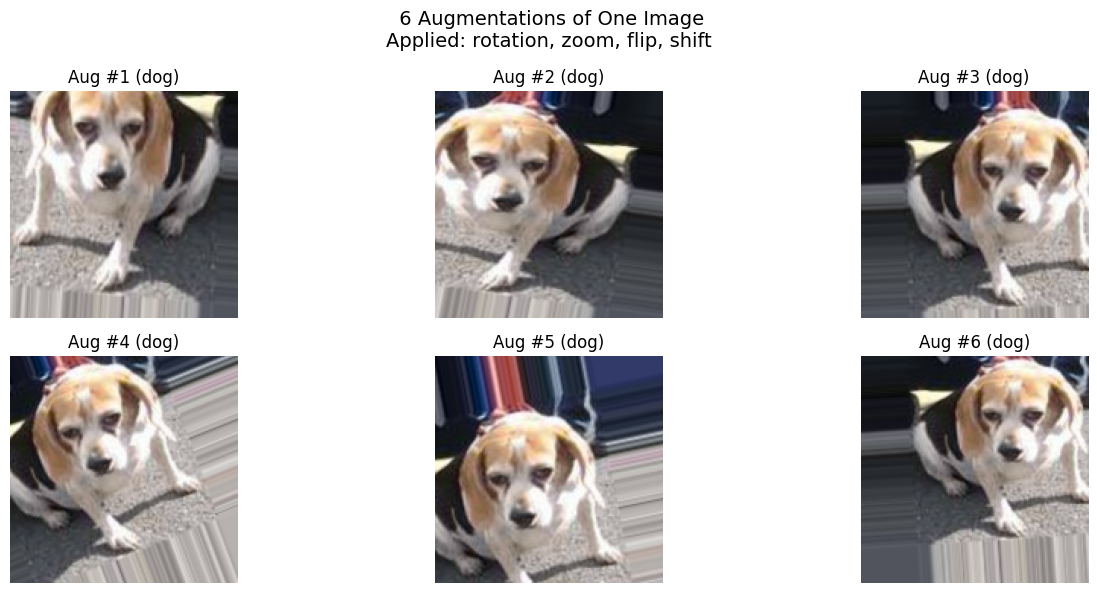

In [9]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import random

# Pick a random image from either 'cat' or 'dog'
category = random.choice(['cat', 'dog'])
img_path = random.choice(sorted((train_dir / category).glob("*.jpg")))

# Load and expand dims
img = image.load_img(img_path, target_size=IMAGE_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # (1, 150, 150, 3)

# Generator for single image
single_aug_gen = train_datagen.flow(img_array, batch_size=1)

# Show 6 augmented versions
plt.figure(figsize=(14, 6))
for i in range(6):
    aug_img = next(single_aug_gen)[0]
    plt.subplot(2, 3, i + 1)
    plt.imshow(aug_img)
    plt.axis('off')
    plt.title(f"Aug #{i+1} ({category})")
plt.suptitle(f" 6 Augmentations of One Image\nApplied: rotation, zoom, flip, shift", fontsize=14)
plt.tight_layout()
plt.show()


### Step 8: Custom CNN Architecture

We build a simple Convolutional Neural Network (CNN) from scratch using the Keras `Sequential` API. The architecture includes:

- 3 Convolution + MaxPooling blocks
- 1 Fully Connected Dense layer with Dropout
- 1 Output layer with Sigmoid for binary classification (Cat vs Dog)

This model is trained using the Adam optimizer and binary cross-entropy loss.


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from pathlib import Path


In [11]:
# Define a basic CNN architecture
model_custom = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary classification
])

# Compile the model
model_custom.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_custom.summary()


c:\Users\singh\anaconda3\envs\nk\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

### Step 9: Training the Custom CNN

We train the custom CNN using the augmented training data. We also apply:

- `EarlyStopping` to stop training when validation loss stops improving
- `ModelCheckpoint` to save the best model during training

This ensures the model does not overfit and only the best weights are retained.


In [12]:
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Paths
base_dir = Path.cwd()
train_dir = base_dir / "kaggle_dogs_vs_cats_small" / "train"
val_dir = base_dir / "kaggle_dogs_vs_cats_small" / "validation"

# Image parameters
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

# Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    str(train_dir),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    str(val_dir),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [13]:
# Path to save best model
Path("models").mkdir(exist_ok=True)

callbacks_custom = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint("models/best_custom_cnn.keras", monitor='val_loss', save_best_only=True, verbose=1)
]


In [14]:
EPOCHS = 10

history_custom = model_custom.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_custom
)


Epoch 1/10


c:\Users\singh\anaconda3\envs\nk\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.5181 - loss: 0.8211
Epoch 1: val_loss improved from inf to 0.68977, saving model to models/best_custom_cnn.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 229ms/step - accuracy: 0.5180 - loss: 0.8197 - val_accuracy: 0.5910 - val_loss: 0.6898
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.5241 - loss: 0.6894
Epoch 2: val_loss did not improve from 0.68977
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - accuracy: 0.5243 - loss: 0.6893 - val_accuracy: 0.5260 - val_loss: 0.6922
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.5193 - loss: 0.6960
Epoch 3: val_loss improved from 0.68977 to 0.67706, saving model to models/best_custom_cnn.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 442ms/step - accuracy: 0.5195 - loss: 0.6959 - val_accuracy: 0.5730 - val_loss: 0.6771
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.5196 - loss: 0.7010
Epoch 4: val_loss improved from 0.67706 to 0.66342, saving model to models/b

### Step 10: Evaluation – Custom CNN

We evaluate the best custom CNN on the test dataset using the following metrics:

- **Accuracy**: Overall correct predictions
- **Confusion Matrix**: Breakdown of true positives, true negatives, etc.
- **Precision, Recall, F1-score**: Classification quality
- **Precision-Recall Curve**: Tradeoff between precision and recall

We also display random predictions and misclassified images for visual interpretation.


In [15]:
# Load best saved model from disk
from tensorflow.keras.models import load_model

model_custom_best = load_model("models/best_custom_cnn.keras")
print(" Best custom CNN model loaded from file.")


 Best custom CNN model loaded from file.


In [16]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
# Required imports
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path

# Define test directory (adjust relative to your current file)
base_dir = Path.cwd()
test_dir = base_dir / "kaggle_dogs_vs_cats_small" / "test"

# Test image generator (no augmentation, only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Define test generator
test_gen = test_datagen.flow_from_directory(
    str(test_dir),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Important: don't shuffle for prediction alignment
)
# Get true labels from test set
y_true = test_gen.classes

# Get predicted probabilities
y_probs = model_custom_best.predict(test_gen).ravel()

# Convert probabilities to binary predictions (0 = cat, 1 = dog)
y_pred = (y_probs >= 0.5).astype(int)


Found 500 images belonging to 2 classes.
 1/16 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step

c:\Users\singh\anaconda3\envs\nk\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


In [18]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print(f" Test Accuracy: {acc:.4f}")


 Test Accuracy: 0.6380


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


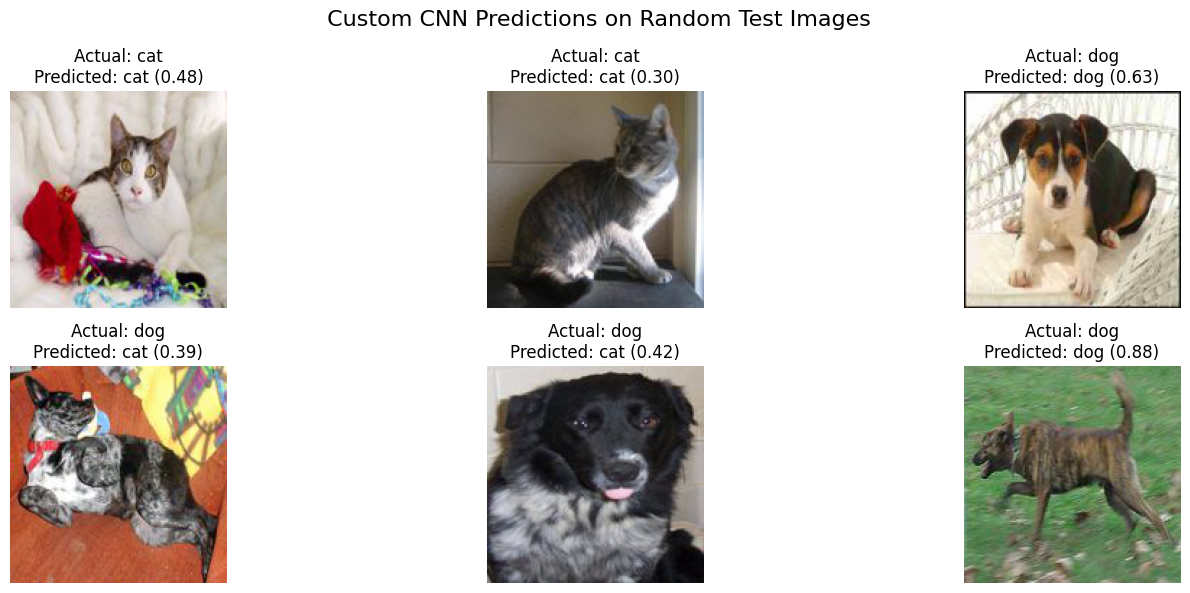

In [19]:
import random
from tensorflow.keras.preprocessing import image

# Get all test image paths and labels
filepaths = np.array(test_gen.filepaths)
true_labels = test_gen.classes
class_indices = {v: k for k, v in test_gen.class_indices.items()}

# Get predictions
y_probs = model_custom_best.predict(test_gen).ravel()
y_pred = (y_probs >= 0.5).astype(int)

# Randomly select 6 indices
random_indices = random.sample(range(len(filepaths)), 6)

# Plot images with predictions
plt.figure(figsize=(16, 6))

for i, idx in enumerate(random_indices):
    img_path = filepaths[idx]
    true_label = class_indices[true_labels[idx]]
    predicted_label = class_indices[y_pred[idx]]
    confidence = y_probs[idx]

    # Load and display image
    img = image.load_img(img_path, target_size=(150, 150))
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Actual: {true_label}\nPredicted: {predicted_label} ({confidence:.2f})")

plt.suptitle(" Custom CNN Predictions on Random Test Images", fontsize=16)
plt.tight_layout()
plt.show()


In [20]:
# Load necessary libraries
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# Load the best saved model from disk
model_custom_best = load_model("models/best_custom_cnn.keras")
print(" Best custom CNN model loaded from disk.")

# Get true labels and filepaths from test generator
y_true = test_gen.classes
filepaths = np.array(test_gen.filepaths)
class_indices = {v: k for k, v in test_gen.class_indices.items()}

# Get prediction probabilities and binary predictions
y_probs = model_custom_best.predict(test_gen).ravel()
y_pred = (y_probs >= 0.5).astype(int)


 Best custom CNN model loaded from disk.
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [21]:

#  Accuracy
acc = accuracy_score(y_true, y_pred)
print(f" Test Accuracy: {acc:.4f}")

 Test Accuracy: 0.6380


In [22]:
#  Classification Report
print(" Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))

 Classification Report:
              precision    recall  f1-score   support

         Cat       0.61      0.75      0.68       250
         Dog       0.68      0.52      0.59       250

    accuracy                           0.64       500
   macro avg       0.65      0.64      0.63       500
weighted avg       0.65      0.64      0.63       500



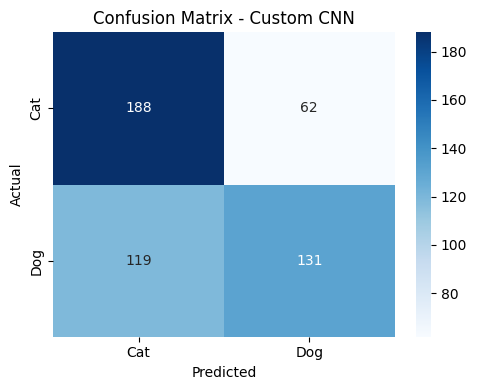

In [23]:

#  Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Custom CNN")
plt.tight_layout()
plt.show()


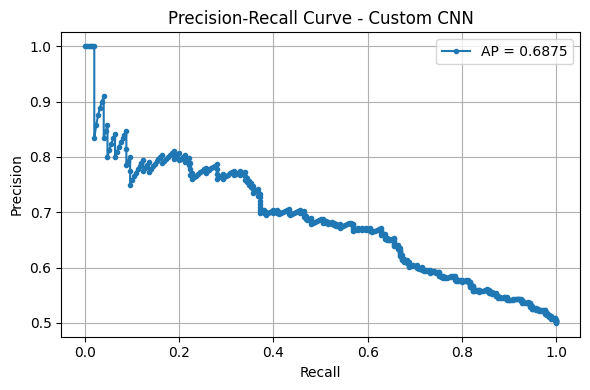

In [24]:
#  Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_probs)
ap_score = average_precision_score(y_true, y_probs)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker='.', label=f'AP = {ap_score:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Custom CNN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


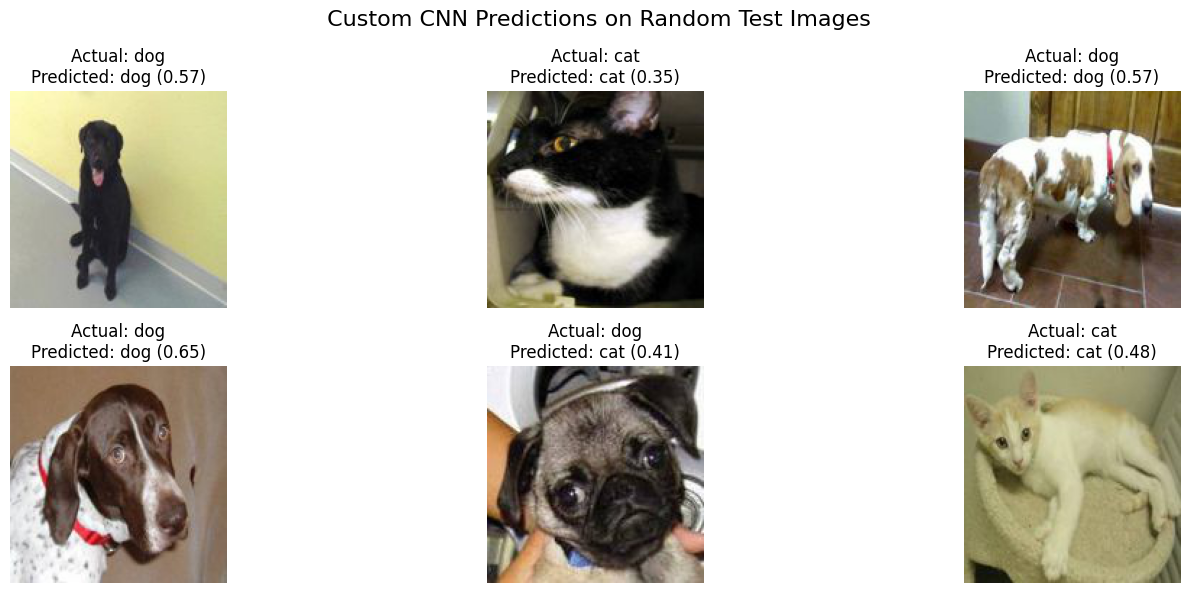

In [25]:
#  Show random predictions
random_indices = random.sample(range(len(filepaths)), 6)
plt.figure(figsize=(16, 6))
for i, idx in enumerate(random_indices):
    img_path = filepaths[idx]
    true_label = class_indices[y_true[idx]]
    predicted_label = class_indices[y_pred[idx]]
    confidence = y_probs[idx]
    img = image.load_img(img_path, target_size=(150, 150))
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Actual: {true_label}\nPredicted: {predicted_label} ({confidence:.2f})")
plt.suptitle(" Custom CNN Predictions on Random Test Images", fontsize=16)
plt.tight_layout()
plt.show()

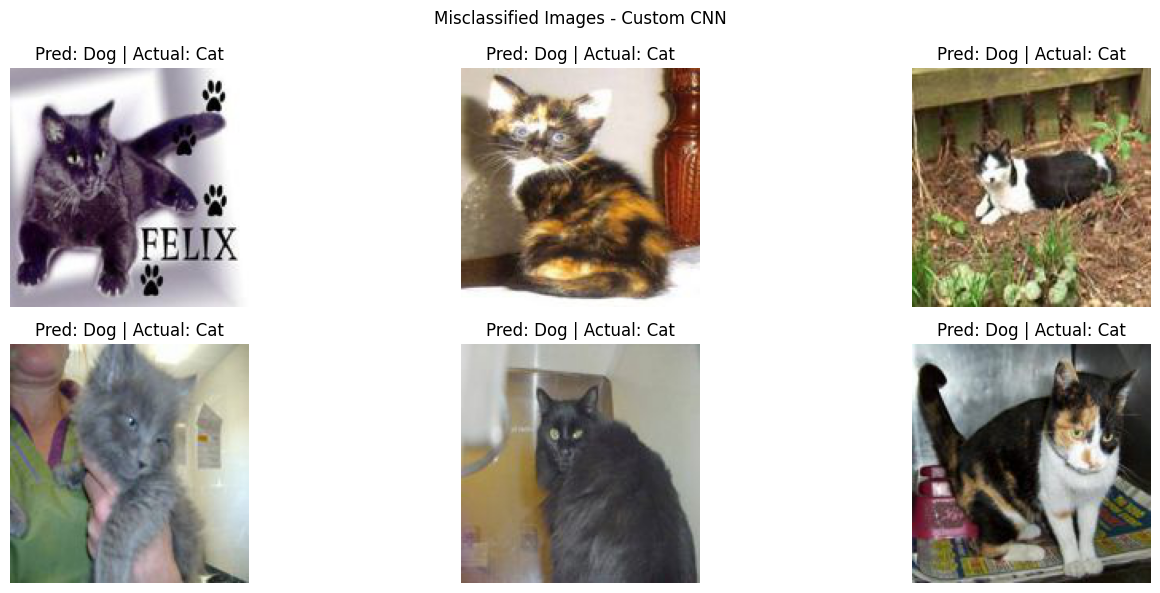

In [26]:
#  Show misclassified examples
misclassified_idx = np.where(y_true != y_pred)[0]
plt.figure(figsize=(15, 6))
for i, idx in enumerate(misclassified_idx[:6]):
    img_path = filepaths[idx]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {'Dog' if y_pred[idx] else 'Cat'} | Actual: {'Dog' if y_true[idx] else 'Cat'}")
    plt.axis('off')
plt.suptitle("Misclassified Images - Custom CNN")
plt.tight_layout()
plt.show()


### Step 11: Load and Fine-Tune VGG16 (Transfer Learning)

We load VGG16, a powerful CNN pre-trained on ImageNet, and fine-tune it for our classification task by:

- Freezing all convolutional layers initially
- Adding custom classifier layers (GAP → Dense → Dropout → Sigmoid)
- Training only the classifier head
- Then unfreezing `block4` and `block5` for fine-tuning

This approach allows us to leverage pre-learned features from a large-scale dataset.


In [27]:

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from pathlib import Path


In [28]:
# Load VGG16 without top classifier
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze all base layers initially
for layer in base_model.layers:
    layer.trainable = False

# Add custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Final model
model_vgg = Model(inputs=base_model.input, outputs=predictions)

# Compile
model_vgg.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model_vgg.summary()


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Step 12: Training VGG16 in Two Phases

**Phase 1:**
- Train only the new classifier head with all VGG layers frozen.

**Phase 2:**
- Unfreeze `block4` and `block5` and continue training with a lower learning rate.

Both phases use early stopping and model checkpointing to ensure optimal performance.


In [29]:
# Create folder if not exists
Path("models").mkdir(exist_ok=True)

callbacks_vgg = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint("models/best_vgg16.keras", monitor='val_loss', save_best_only=True, verbose=1)
]


In [30]:
EPOCHS =10

history_vgg = model_vgg.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_vgg
)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 872ms/step - accuracy: 0.4738 - loss: 0.7888
Epoch 1: val_loss improved from inf to 0.66536, saving model to models/best_vgg16.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.4740 - loss: 0.7884 - val_accuracy: 0.5770 - val_loss: 0.6654
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5484 - loss: 0.7036   
Epoch 2: val_loss improved from 0.66536 to 0.61684, saving model to models/best_vgg16.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.5484 - loss: 0.7035 - val_accuracy: 0.7730 - val_loss: 0.6168
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.6015 - loss: 0.6678
Epoch 3: val_loss improved from 0.61684 to 0.57637, saving model to models/best_vgg16.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6017 - loss: 0.6677 - val_accuracy: 0.8150 - val_loss: 0.5764
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 869ms/step - accuracy: 0.6415 - loss: 0.6264
Epoch 4: val_loss improved from 0.57637

In [31]:
# Unfreeze block4 and block5 for fine-tuning
for layer in model_vgg.layers:
    if 'block4' in layer.name or 'block5' in layer.name:
        layer.trainable = True

# Recompile with a lower learning rate
model_vgg.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [32]:
callbacks_vgg_ft = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint("models/best_vgg16_finetuned.keras", monitor='val_loss', save_best_only=True, verbose=1)
]


In [33]:
EPOCHS_FINE =10

history_vgg_ft = model_vgg.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=callbacks_vgg_ft
)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8217 - loss: 0.4132
Epoch 1: val_loss improved from inf to 0.22130, saving model to models/best_vgg16_finetuned.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8219 - loss: 0.4126 - val_accuracy: 0.9140 - val_loss: 0.2213
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8713 - loss: 0.3066
Epoch 2: val_loss improved from 0.22130 to 0.16081, saving model to models/best_vgg16_finetuned.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8716 - loss: 0.3061 - val_accuracy: 0.9250 - val_loss: 0.1608
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9008 - loss: 0.2494
Epoch 3: val_loss improved from 0.16081 to 0.14991, saving model to models/best_vgg16_finetuned.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9008 - loss: 0.2493 - val_accuracy: 0.9360 - val_loss: 0.1499
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9096 - loss: 0.2113
Epoch 4: val_loss 

In [34]:
#  Required imports
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from tensorflow.keras.preprocessing import image
import tensorflow as tf

#  Load fine-tuned VGG16 model from disk
model_vgg_best = load_model("models/best_vgg16_finetuned.keras")
print(" Fine-tuned VGG16 model loaded from disk.")

# Get true labels and filepaths from test generator
y_true_vgg = test_gen.classes
filepaths_vgg = np.array(test_gen.filepaths)
class_indices_vgg = {v: k for k, v in test_gen.class_indices.items()}

# Get predictions and binary classification
y_probs_vgg = model_vgg_best.predict(test_gen).ravel()
y_pred_vgg = (y_probs_vgg >= 0.5).astype(int)

 Fine-tuned VGG16 model loaded from disk.
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 871ms/step


### Step 13: Evaluation – Fine-Tuned VGG16

We evaluate the fine-tuned VGG16 model on the test set using the same metrics:

- Accuracy
- Confusion Matrix
- Classification Report
- Precision-Recall Curve
- Random Predictions
- Misclassified Images

This allows for fair comparison with the custom CNN.


In [35]:
#  Accuracy
acc_vgg = accuracy_score(y_true_vgg, y_pred_vgg)
print(f" Test Accuracy (VGG16): {acc_vgg:.4f}")

 Test Accuracy (VGG16): 0.9400


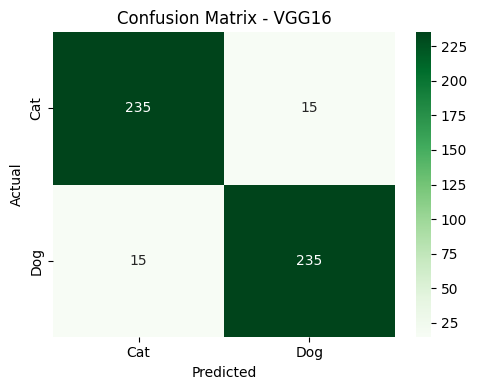

In [36]:
#  Confusion Matrix
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Greens', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - VGG16")
plt.tight_layout()
plt.show()

In [37]:
#  Classification Report
print(" Classification Report (VGG16):")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=['Cat', 'Dog']))

 Classification Report (VGG16):
              precision    recall  f1-score   support

         Cat       0.94      0.94      0.94       250
         Dog       0.94      0.94      0.94       250

    accuracy                           0.94       500
   macro avg       0.94      0.94      0.94       500
weighted avg       0.94      0.94      0.94       500



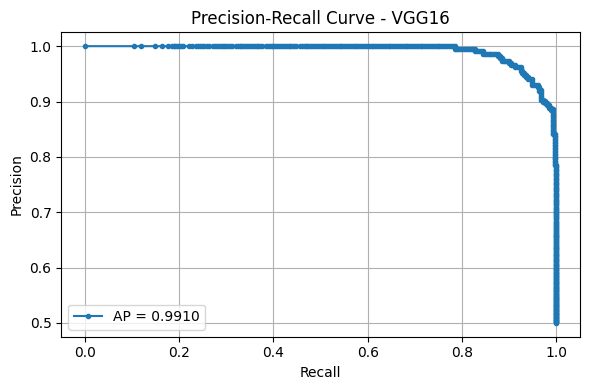

In [38]:
#  Precision-Recall Curve
precision_vgg, recall_vgg, _ = precision_recall_curve(y_true_vgg, y_probs_vgg)
ap_vgg = average_precision_score(y_true_vgg, y_probs_vgg)

plt.figure(figsize=(6, 4))
plt.plot(recall_vgg, precision_vgg, marker='.', label=f'AP = {ap_vgg:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - VGG16")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

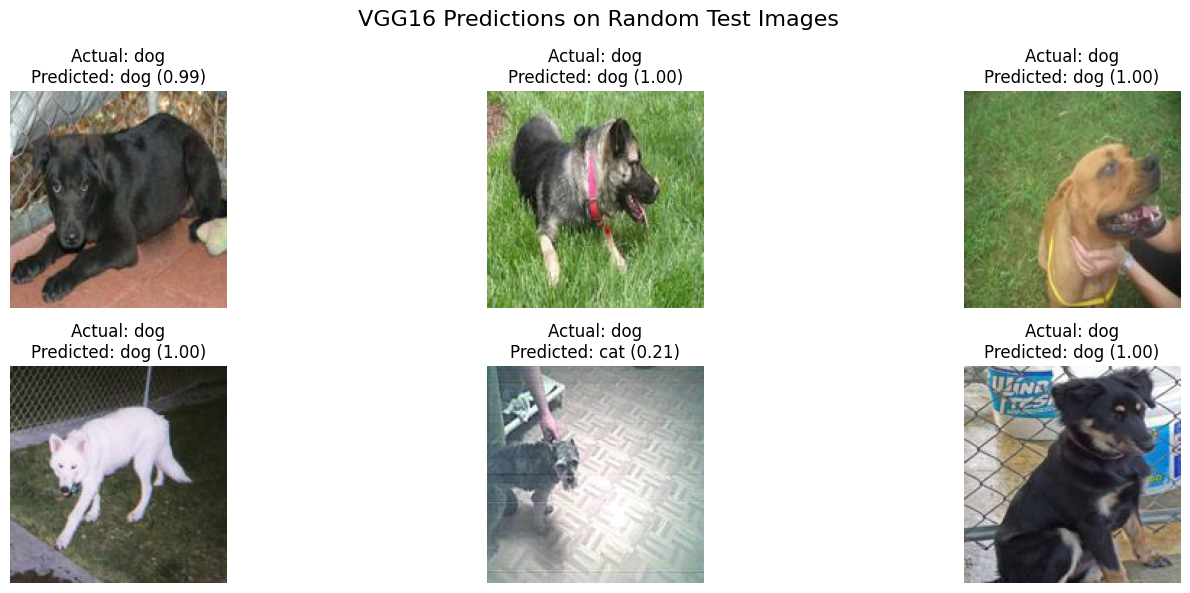

In [39]:

#  Random Predictions from Test Set
random_indices_vgg = random.sample(range(len(filepaths_vgg)), 6)
plt.figure(figsize=(16, 6))
for i, idx in enumerate(random_indices_vgg):
    img_path = filepaths_vgg[idx]
    true_label = class_indices_vgg[y_true_vgg[idx]]
    predicted_label = class_indices_vgg[y_pred_vgg[idx]]
    confidence = y_probs_vgg[idx]
    img = image.load_img(img_path, target_size=(150, 150))
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Actual: {true_label}\nPredicted: {predicted_label} ({confidence:.2f})")
plt.suptitle(" VGG16 Predictions on Random Test Images", fontsize=16)
plt.tight_layout()
plt.show()

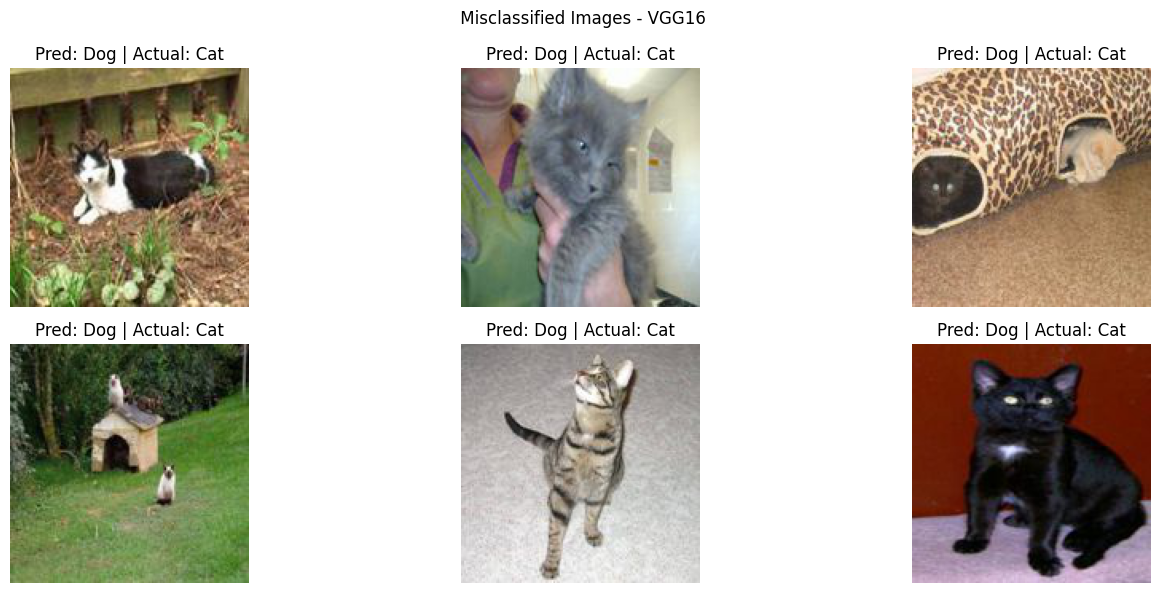

In [40]:

#  Misclassified Samples
misclassified_idx_vgg = np.where(y_true_vgg != y_pred_vgg)[0]
plt.figure(figsize=(15, 6))
for i, idx in enumerate(misclassified_idx_vgg[:6]):
    img_path = filepaths_vgg[idx]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {'Dog' if y_pred_vgg[idx] else 'Cat'} | Actual: {'Dog' if y_true_vgg[idx] else 'Cat'}")
    plt.axis('off')
plt.suptitle(" Misclassified Images - VGG16")
plt.tight_layout()
plt.show()

### Step 14: Custom CNN vs Fine-Tuned VGG16 Comparison

We compare both models using:

- Bar plot of Accuracy, Precision, Recall, F1-Score, Average Precision
- Side-by-side Confusion Matrices
- Precision-Recall Curves

The comparison helps highlight how transfer learning (VGG16) significantly improves performance over a custom CNN trained from scratch.


In [41]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, average_precision_score

# Custom CNN metrics
acc_cnn = accuracy_score(y_true, y_pred)
prec_cnn = precision_score(y_true, y_pred)
rec_cnn = recall_score(y_true, y_pred)
f1_cnn = f1_score(y_true, y_pred)
ap_cnn = average_precision_score(y_true, y_probs)

# Now safe to print
print(f"Accuracy (Custom CNN)   : {acc_cnn:.4f}")
print(f" Accuracy (VGG16 FineTune): {acc_vgg:.4f}")


Accuracy (Custom CNN)   : 0.6380
 Accuracy (VGG16 FineTune): 0.9400


In [42]:
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

#  Make sure the following are already defined:
# y_true_vgg = test_gen.classes
# y_pred_vgg = (y_probs_vgg >= 0.5).astype(int)
# y_probs_vgg = model_vgg_best.predict(test_gen).ravel()

# VGG16 metrics
prec_vgg = precision_score(y_true_vgg, y_pred_vgg)
rec_vgg = recall_score(y_true_vgg, y_pred_vgg)
f1_vgg = f1_score(y_true_vgg, y_pred_vgg)
ap_vgg = average_precision_score(y_true_vgg, y_probs_vgg)


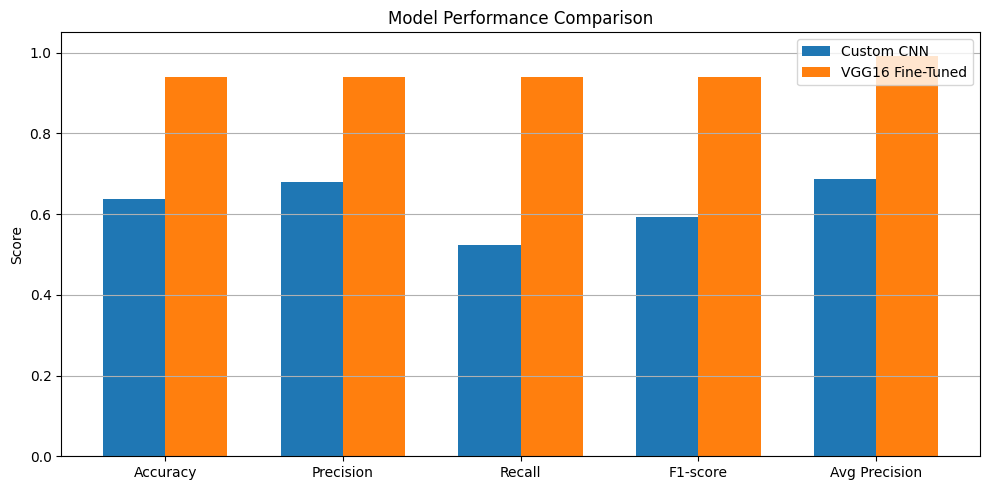

In [43]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Accuracy", "Precision", "Recall", "F1-score", "Avg Precision"]
cnn_scores = [acc_cnn, prec_cnn, rec_cnn, f1_cnn, ap_cnn]
vgg_scores = [acc_vgg, prec_vgg, rec_vgg, f1_vgg, ap_vgg]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, cnn_scores, width, label='Custom CNN')
plt.bar(x + width/2, vgg_scores, width, label='VGG16 Fine-Tuned')

plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(x, labels)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


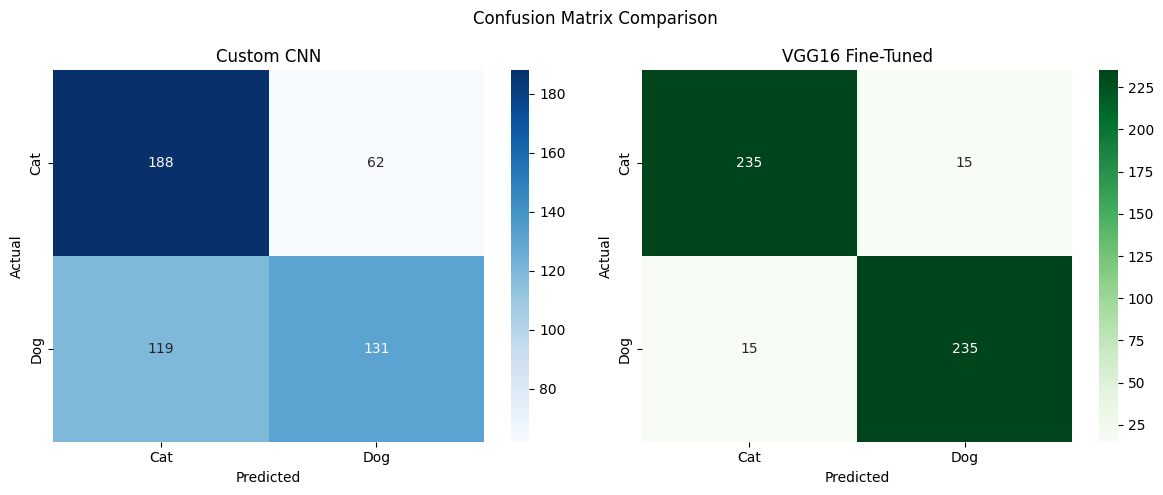

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Custom CNN
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'],
            cmap='Blues', ax=axes[0])
axes[0].set_title("Custom CNN")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# VGG16
sns.heatmap(confusion_matrix(y_true_vgg, y_pred_vgg), annot=True, fmt='d',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'],
            cmap='Greens', ax=axes[1])
axes[1].set_title("VGG16 Fine-Tuned")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison")
plt.tight_layout()
plt.show()


In [45]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Custom CNN
acc_cnn = accuracy_score(y_true, y_pred)
prec_cnn = precision_score(y_true, y_pred)
rec_cnn = recall_score(y_true, y_pred)
f1_cnn = f1_score(y_true, y_pred)
ap_cnn = average_precision_score(y_true, y_probs)

# VGG16
acc_vgg = accuracy_score(y_true_vgg, y_pred_vgg)
prec_vgg = precision_score(y_true_vgg, y_pred_vgg)
rec_vgg = recall_score(y_true_vgg, y_pred_vgg)
f1_vgg = f1_score(y_true_vgg, y_pred_vgg)
ap_vgg = average_precision_score(y_true_vgg, y_probs_vgg)

# Display in table
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Avg Precision (PR AUC)"],
    "Custom CNN": [f"{acc_cnn:.4f}", f"{prec_cnn:.4f}", f"{rec_cnn:.4f}", f"{f1_cnn:.4f}", f"{ap_cnn:.4f}"],
    "VGG16 Fine-Tuned": [f"{acc_vgg:.4f}", f"{prec_vgg:.4f}", f"{rec_vgg:.4f}", f"{f1_vgg:.4f}", f"{ap_vgg:.4f}"]
}

df_compare = pd.DataFrame(comparison_data)
import pandas as pd
from IPython.display import display
display(df_compare)


,Metric,Custom CNN,VGG16 Fine-Tuned
0,Accuracy,0.6380,0.9400
1,Precision,0.6788,0.9400
2,Recall,0.5240,0.9400
3,F1-score,0.5914,0.9400
4,Avg Precision (PR AUC),0.6875,0.9910


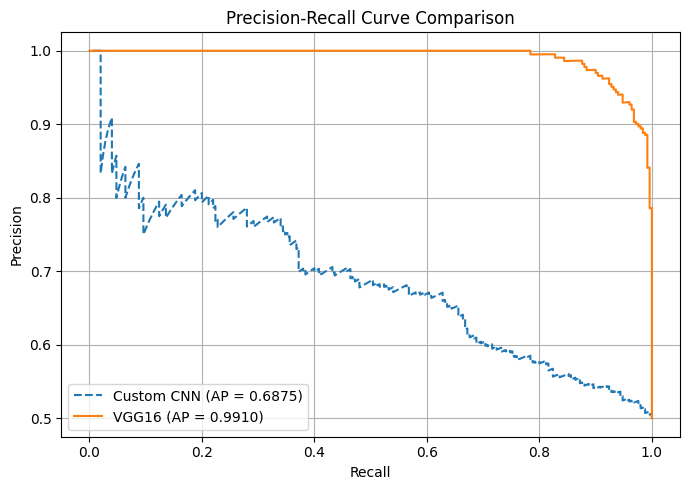

In [46]:
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'Custom CNN (AP = {ap_cnn:.4f})', linestyle='--')
plt.plot(recall_vgg, precision_vgg, label=f'VGG16 (AP = {ap_vgg:.4f})', linestyle='-')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Step 15: Analysis of Misclassifications

We analyze cases where the custom CNN predicted incorrectly, but VGG16 got it right.

This highlights the power of transfer learning and shows how pre-trained models handle more complex visual patterns better than basic models.


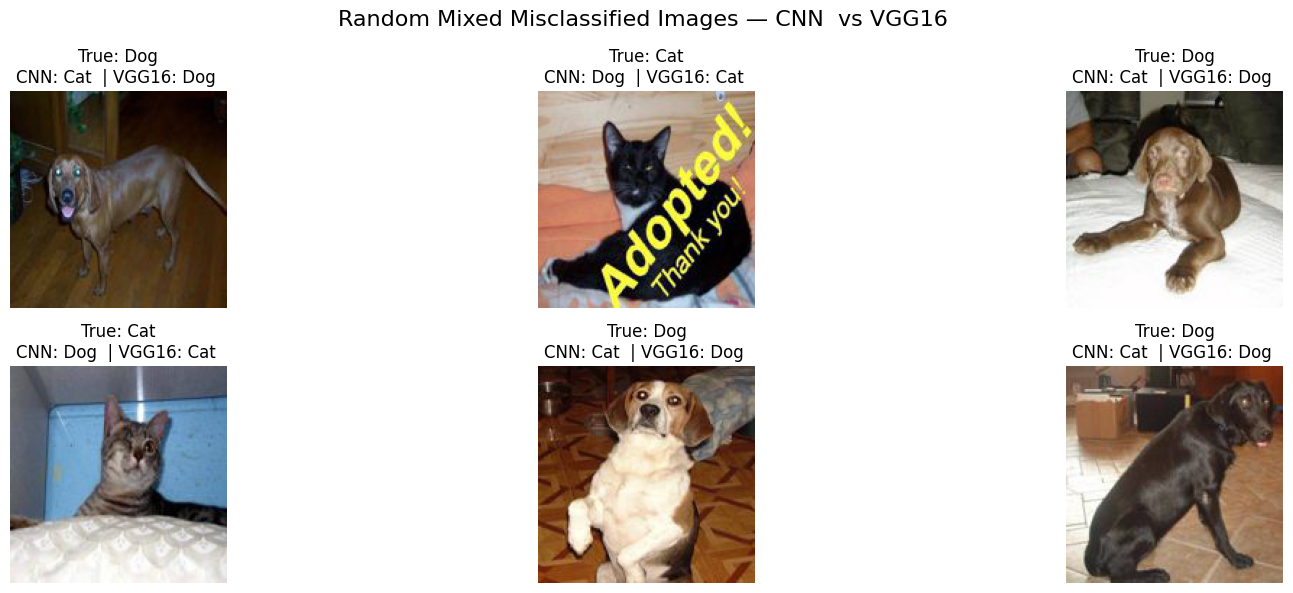

In [47]:
import random
import matplotlib.pyplot as plt
import tensorflow as tf

# Step 1: Find indices where CNN failed and VGG16 got it right
mis_cnn_correct_vgg = np.where((y_pred != y_true) & (y_pred_vgg == y_true))[0]

# Step 2: Randomly select up to 6 such samples
selected_indices = random.sample(list(mis_cnn_correct_vgg), min(6, len(mis_cnn_correct_vgg)))

# Step 3: Plot them
plt.figure(figsize=(18, 6))
for i, idx in enumerate(selected_indices):
    img_path = test_gen.filepaths[idx]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
    
    true_label = 'Dog' if y_true[idx] else 'Cat'
    cnn_label = 'Dog' if y_pred[idx] else 'Cat'
    vgg_label = 'Dog' if y_pred_vgg[idx] else 'Cat'

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {true_label}\nCNN: {cnn_label}  | VGG16: {vgg_label} ")

plt.suptitle("Random Mixed Misclassified Images — CNN  vs VGG16 ", fontsize=16)
plt.tight_layout()
plt.show()


### Conclusion and Insights

- **Fine-tuned VGG16** consistently outperforms the custom CNN in all evaluation metrics.
- **Data augmentation** was crucial in improving both models' generalization.
- **Transfer learning** allows models to start with strong feature extractors, even on small datasets.
- Misclassified image analysis confirmed that VGG16 is more robust in edge cases.

This project demonstrates the importance of leveraging pre-trained architectures and rigorous evaluation to build high-performing deep learning models.
